# 05c — Confronto sulla split test a lunghezza del riferimento

I quattro notebook di confronto **non generano nulla**: leggono i file di metriche salvati in
`results/metrics/` e costruiscono tabelle e grafici; si possono eseguire in qualunque momento,
su qualunque sottoinsieme di risultati disponibile (i metodi mancanti vengono saltati). Gli
helper comuni — elenco dei 18 slug, palette, caricamento con intersezione dei `row_id`, tabella
delle medie, grafici a barre — stanno in `summ_utils.py` (sezione *Confronto fra metodi*).

| notebook | ambito | contenuto |
|---|---|---|
| **05a** | `full` | TextRank vs LexRank sull'intero dataset (56.101 esempi) |
| **05b** | `test` | tutti i 18 metodi sulla split test: **il confronto principale del benchmark** |
| **05c** | `test_budgetref` | gli stessi 18 a lunghezza del riferimento, stessa presentazione di 05b |
| **05d** | `test` → `test_budgetref` | prima/dopo il riallineamento: metriche, dispersione, G-Eval |

## Ambito `test_budgetref`

Gli stessi 18 metodi del notebook 05b, ma con — per ogni cluster — **lo stesso budget di
parole: la lunghezza del riassunto di riferimento** (issue #16), il protocollo *length-matched*
/ *oracle-length* (Sun et al., 2019). Il notebook 18 mostra che così come generano i metodi
producono riassunti di lunghezza molto diversa dentro lo stesso cluster (il più lungo dei 18 è
in mediana 8,5 volte il più corto) e che la lunghezza spiega da sola gran parte del ROUGE
*recall*; con `|candidato| ≈ |riferimento|` richiamo e precisione coincidono e l'obiezione «i
riassunti lunghi vincono sul recall» non può più nascere per costruzione.

Come è stato applicato (dettagli in `scripts/applica_budget.py` e nei singoli notebook):

- **Tetto per tutti e 18**: troncamento a `1,25 × budget` (`su.tronca_parole`), riga per riga.
- **Rigenerazione a budget per gli 11 estrattivi** (01, 02, 10, 11, 15, 16, 17): budget in
  *parole* al posto del budget in *frasi*, stesso criterio di ordinamento di ciascun metodo
  (`su.seleziona_per_budget`).
- **Rigenerazione a budget per gli LLM** (07, 08, 09, 12): budget **nel prompt** («about *N*
  words, at least *N* words»), fattore calibrato per modello su un pilota da 30 righe (`qwen`
  1,2, `gemma` 0,9, `mistral` 1,0, `gpt5mini` 0,9: i modelli sbagliano in direzioni opposte).
  Un LLM segue l'istruzione solo approssimativamente: la quota in banda è un risultato misurato.
- **Solo tetto per `bart`, `pegasus`, `primera`**, per scelta: rigenerarli passerebbe da
  `min_length`, cioè forzerebbe il beam search oltre la lunghezza naturale — il meccanismo dei
  loop di ripetizione già documentati per PEGASUS. `pegasus` (0,83×) e `primera` (0,97×) sono
  comunque già dentro o al bordo della banda; **`bart` (0,26×, 0,3% in banda) è l'eccezione
  dichiarata** del confronto e va letto come tale.

⚠️ **Come leggere i numeri.** Il budget usa un'informazione gold — la sola *lunghezza* del
riferimento, mai il contenuto — quindi risponde a «quanto è buona la selezione dei contenuti a
parità di lunghezza», **non** a «cosa otterrebbe il metodo in produzione». Non sono numeri di
testa del benchmark: sono il controllo che rende il notebook 05b leggibile senza il confondente
della lunghezza. Il prima/dopo è nel notebook 05d.

ℹ️ **G-Eval**: ricalcolato su questo ambito con lo stesso giudice `gpt-5.4-mini`, sui testi
**dopo il tetto** (gli stessi su cui sono calcolate le altre metriche), riusando i giudizi già
in cache per i testi rimasti identici (`bart` 94%, `pegasus` 84%, `primera` 74%); 100.712
giudizi, 99.040 riusciti. La copertura è più alta che nell'ambito `test` (5.483–5.554 righe per
metodo): stessa risorsa e stesso filtro, ma il content filter di Azure varia fra una corsa e
l'altra.

⚠️ **`mistral` segue l'istruzione di lunghezza in modo molto disperso** (p10 0,76×, p90 1,98×):
71% in banda contro il 99–100% di `gemma` e `gpt5mini`. È una proprietà del modello, misurata.

⚠️ **Content filter di Azure e filtro custom per `gpt5mini`**: la severità del filtro è
configurata **per risorsa**. La prima corsa sul nuovo account copriva solo 5.250 righe su 5.610
(360 rifiuti) contro le 5.471 della corsa `test`. Attaccando al deployment un **filtro custom
permissivo** (`Guardrails760`, solo severità alta) e rilanciando le sole righe mancanti se ne
sono recuperate 312: copertura **5.562/5.610 = 99,1%** e intersezione comune ai 18 metodi a
**5.527** cluster. Stessa risorsa, modello, prompt e parametri: cambia solo la policy del
filtro, che regola l'*accesso* e non altera la generazione. Riprodurre la corsa richiede il
filtro custom sul deployment.

⚠️ **METEOR di `lda` e `lexrank` non affidabile su questo ambito**: sulla riga 50540 — una
sorgente degenere, un elenco di nomi di birrifici — la formula non limitata di pyAutoSummarizer
produce −77.557 per `lda` e −3.074 per `lexrank`, trascinando le medie a −13,5 e −0,16 contro
valori reali di ~0,40 e ~0,39 senza quella riga. ROUGE/BLEU non ne risentono. Nessun file è
stato modificato per questo.

⚠️ Nota sui valori assoluti: il ROUGE di pyAutoSummarizer usa insiemi di n-grammi *unici*
(non i conteggi "clipped" del ROUGE ufficiale), quindi i numeri sono confrontabili **tra i metodi
di questo benchmark** ma non direttamente con la letteratura; i valori del paper di Multi-News
sono riportati in fondo al notebook 05b solo come contesto qualitativo.

In [1]:
# --- Configurazione ---------------------------------------------------------
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import summ_utils as su

BASE = su.trova_base_dir()
P = su.percorsi_standard(BASE)
su.stile_grafici()

# Palette e costanti condivise dai notebook 05a-05d (definite una volta in summ_utils)
COLORI = su.COLORI_METODI
INK, INK2, MUTED, GRID, SURFACE = su.INK, su.INK2, su.MUTED, su.GRID, su.SURFACE
METODI = su.METODI_BENCHMARK

budget_dati = su.carica_scope(P['metrics_dir'], 'test_budgetref', METODI)


def rigenerato(metodo):
    """True se il metodo e' stato rigenerato a budget (non solo troncato al tetto)."""
    return bool(budget_dati[metodo]['agg'].get('config', {}).get('ambito_budget', {})
                .get('rigenerato_a_budget'))


# Quota di cluster in banda [0,8, 1,25] x riferimento: dal notebook 18 su questo ambito
analisi_path = P['metrics_dir'] / 'analisi_lunghezze_test_budgetref.json'
in_banda = {}
if analisi_path.exists():
    with open(analisi_path, encoding='utf-8') as f:
        in_banda = {m: v['pct_in_banda'] for m, v in json.load(f)['per_metodo'].items()}

if budget_dati:
    stato = pd.DataFrame({'rigenerato a budget': {m: rigenerato(m) for m in budget_dati},
                          'in banda %': {m: in_banda.get(m) for m in budget_dati}})
    print(f'{int(stato["rigenerato a budget"].sum())} metodi rigenerati a budget, '
          f'{len(stato) - int(stato["rigenerato a budget"].sum())} col solo tetto.')
    display(stato.loc[[m for m in METODI if m in budget_dati]])

test_budgetref: confronto su 5527 esempi comuni a 18 metodi con copertura piena
15 metodi rigenerati a budget, 3 col solo tetto.


,rigenerato a budget,in banda %
firstk_psr,True,98.0
firstk_nltk,True,98.1
centroid_mmr,True,97.5
centroid_mmr_bert,True,97.5
textrank,True,97.6
lexrank,True,97.2
bart,False,0.3
pegasus,False,52.1
primera,False,65.9
qwen,True,79.2


## Tabella e grafici

Stessa presentazione del notebook 05b: le stesse tabelle e gli stessi grafici, sull'ambito a lunghezza del riferimento.

Medie — split test a lunghezza del riferimento:


,rouge1_f1,rouge2_f1,rougeL_f1,bleu,meteor,bertscore_f1,geval_media,parole_generate,n_esempi,n_geval
firstk_psr,0.3683,0.1293,0.1903,0.1043,0.4072,0.8439,2.8555,214.3642,5527.0,5477.0
firstk_nltk,0.3680,0.1295,0.1900,0.1046,0.4062,0.8470,3.3814,214.4295,5527.0,5470.0
centroid_mmr,0.3780,0.1369,0.1974,0.1155,0.4127,0.8469,2.7947,214.8468,5527.0,5466.0
centroid_mmr_bert,0.3643,0.1269,0.1919,0.1106,0.4133,0.8456,2.7913,214.7351,5527.0,5464.0
textrank,0.3594,0.1240,0.1848,0.1053,0.4027,0.8432,2.5735,214.8107,5527.0,5465.0
lexrank,0.3517,0.1228,0.1824,0.1041,-0.1626,0.8395,2.4642,215.4919,5527.0,5464.0
bart,0.2656,0.0815,0.1469,0.0174,0.1694,0.8541,4.4644,55.1860,5527.0,5495.0
pegasus,0.4247,0.1811,0.2408,0.1330,0.0721,0.8714,4.0306,175.1346,5527.0,5494.0
primera,0.4461,0.1982,0.2503,0.1497,0.4687,0.8746,4.2241,201.0593,5527.0,5491.0
qwen,0.3513,0.1130,0.1929,0.0798,0.4049,0.8620,4.6838,216.1321,5527.0,5464.0


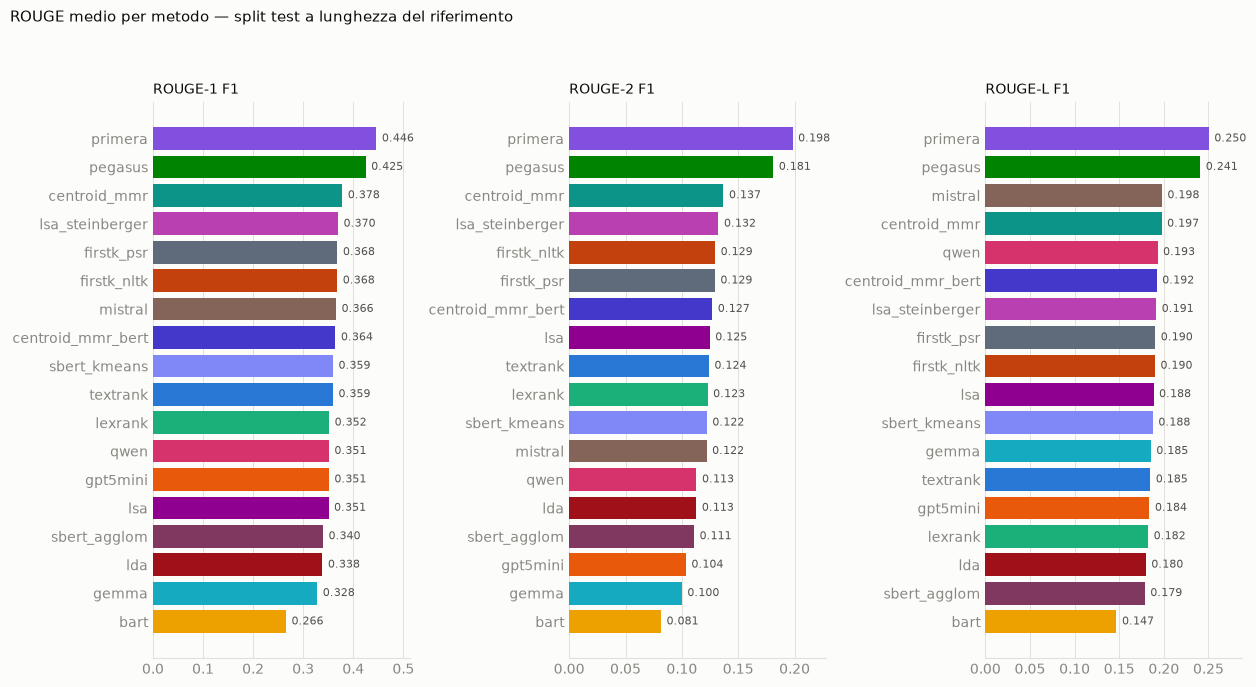

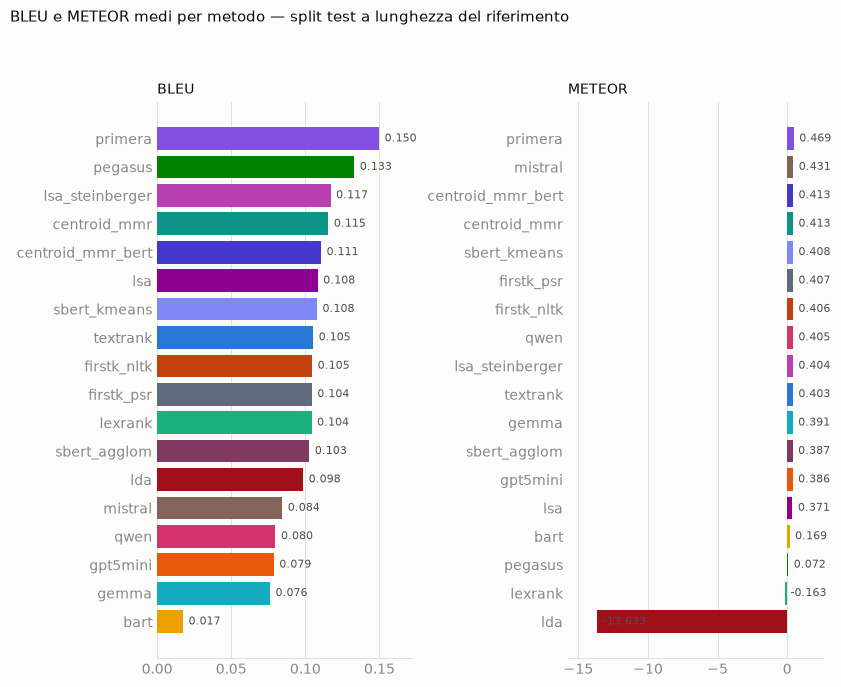

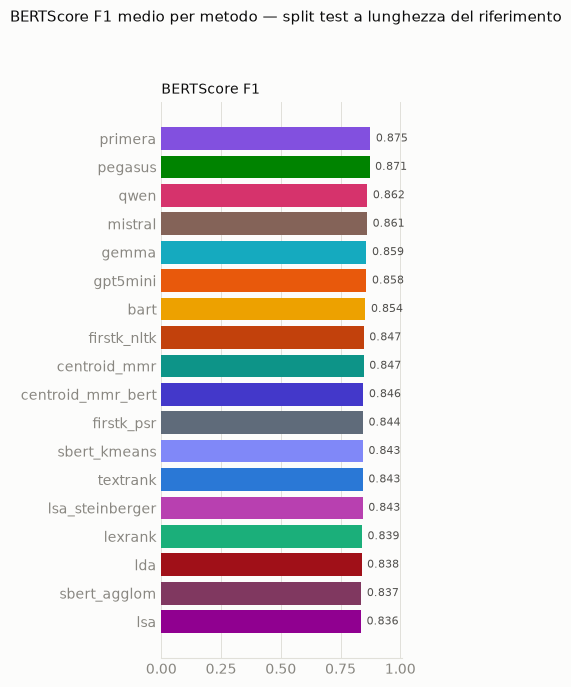

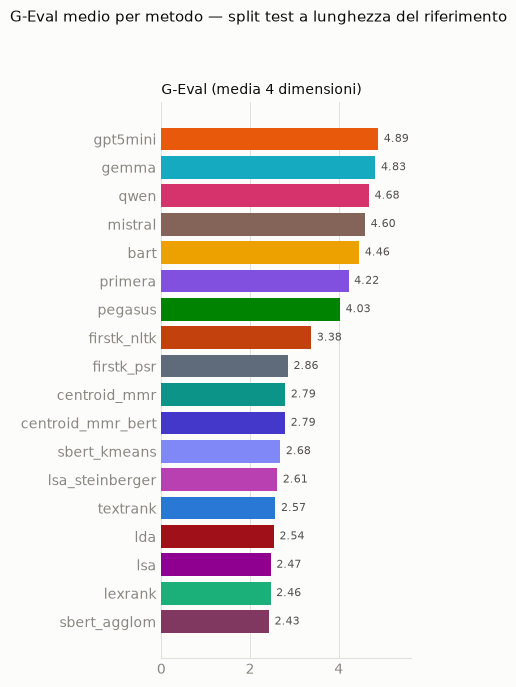

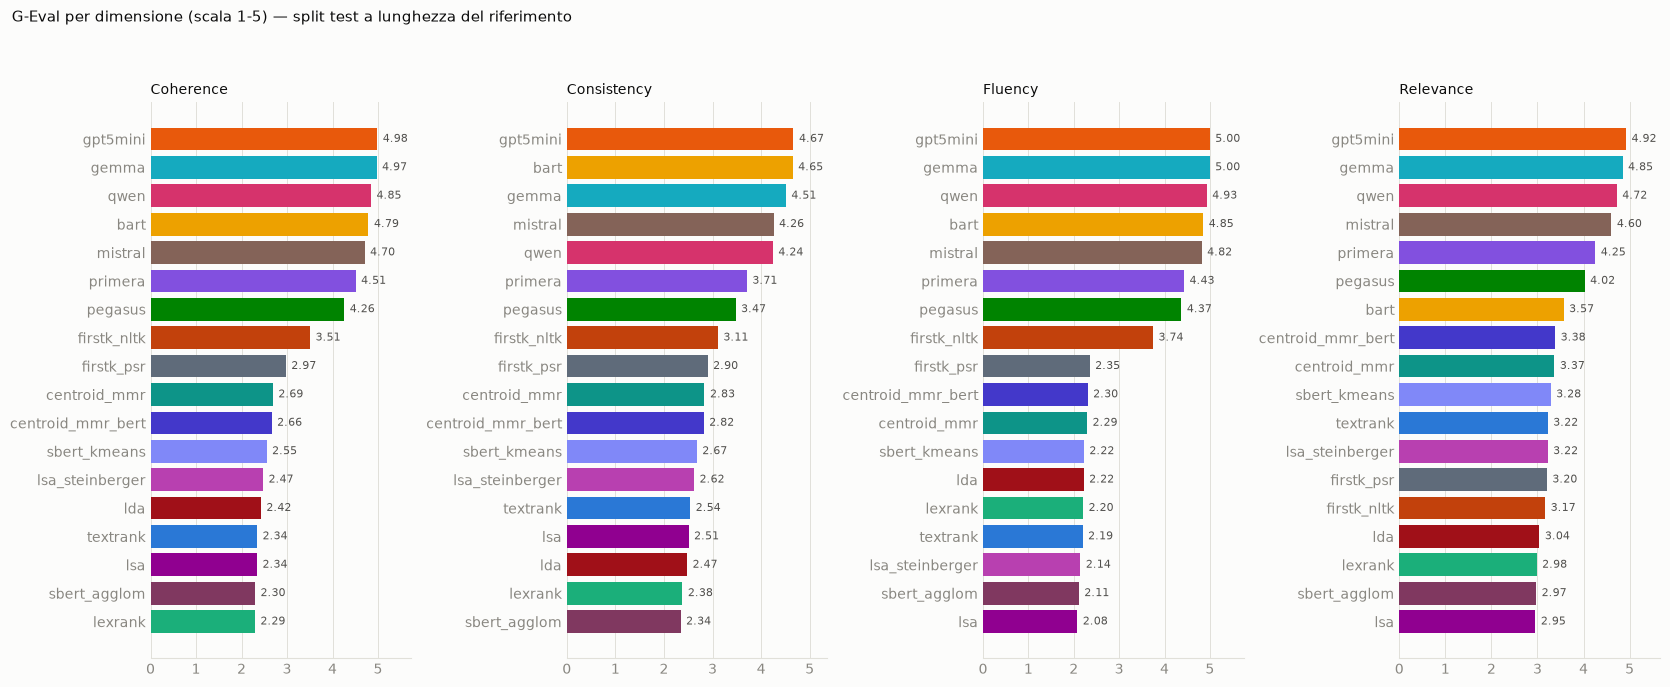

In [2]:
if budget_dati:
    su.viste_metriche(budget_dati, 'split test a lunghezza del riferimento')
else:
    print("Ambito 'test_budgetref' non disponibile: eseguire scripts/run_benchmark_test.py "
          "--scope test_budgetref e poi scripts/applica_budget.py.")